<a href="https://colab.research.google.com/github/samuelorozco641/Seminario_Ciencia_Datos/blob/main/Laboratorio_Transf_caracteristicas_SamuelOrozco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Transformación de características
# Escalamiento
# Min-Max Scaling y Estandarización (Z-Score)

In [22]:
# =========================================
# OBJETIVO
# =========================================
# Comprender cómo funcionan las transformaciones de escalamiento
# y cómo afectan los datos en análisis y modelos.

In [23]:
# =========================================
# 📘 PARTE 1: CONCEPTO TEÓRICO
# =========================================

In [24]:
# Min-Max Scaling:
# Lleva los datos a un rango entre 0 y 1
# Fórmula:
# X' = (X - min) / (max - min)

# Z-Score:
# Centra los datos en 0 usando la media
# Fórmula:
# Z = (X - media) / desviación estándar

In [25]:
# =========================================
# 📊 PARTE 2: CASO DE USO
# =========================================

# Supongamos que tenemos datos de clientes
# Problema: ingresos domina sobre edad

In [26]:
import pandas as pd

# Dataset base

data = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 10000000]
})

print("\n📊 Datos originales:\n")
print(data)


📊 Datos originales:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  10000000


In [27]:
# =========================================
# 🔹 PARTE 3: MIN-MAX SCALING
# =========================================

from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
scaler = MinMaxScaler()

# Aplicamos transformación
minmax_data = scaler.fit_transform(data)

# Convertimos a DataFrame
minmax_df = pd.DataFrame(minmax_data, columns=data.columns)

print("\n🔹 Datos con Min-Max Scaling:\n")
print(minmax_df)

# 💡 Observa:
# - Todos los valores están entre 0 y 1
# - Se mantiene la proporción


🔹 Datos con Min-Max Scaling:

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.055556
2  0.333333  0.222222
3  0.666667  0.666667
4  1.000000  1.000000


In [28]:
# =========================================
# 🔹 PARTE 4: Z-SCORE (ESTANDARIZACIÓN)
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

zscore_data = scaler.fit_transform(data)

zscore_df = pd.DataFrame(zscore_data, columns=data.columns)

print("\n🔹 Datos con Z-Score:\n")
print(zscore_df)

# 💡 Observa:
# - Valores alrededor de 0
# - Negativos = debajo del promedio
# - Positivos = encima del promedio


🔹 Datos con Z-Score:

       edad   ingreso
0 -1.207020 -1.010363
1 -0.742781 -0.866025
2 -0.278543 -0.433013
3  0.649934  0.721688
4  1.578410  1.587713


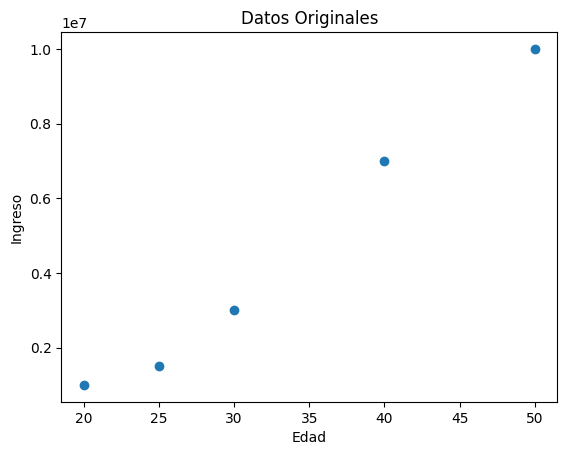

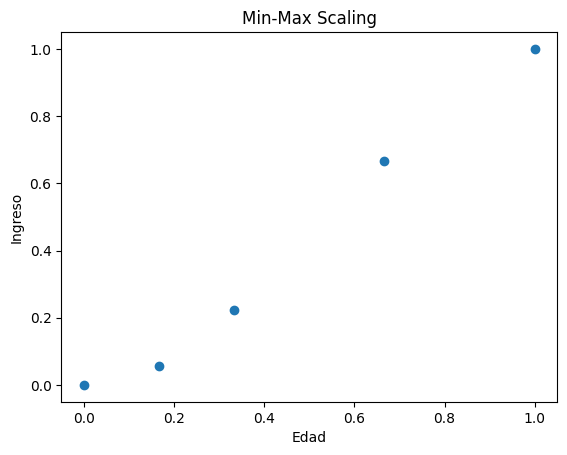

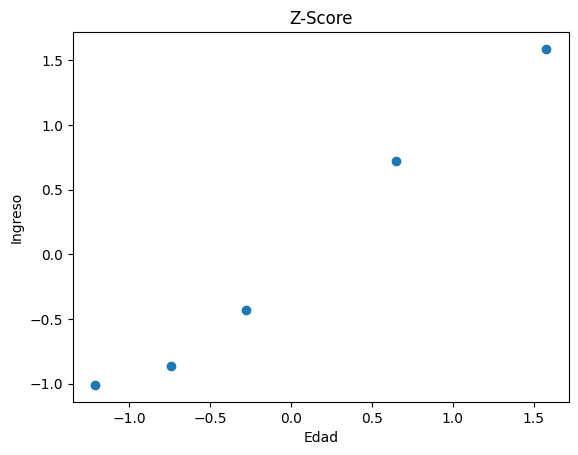

In [29]:
# =========================================
# 🧪 PARTE 5: VISUALIZACIÓN
# =========================================

#“Comparar cómo cambian los datos antes y después de aplicar transformaciones”

import matplotlib.pyplot as plt

# Datos originales
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos Originales")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# MinMax
plt.scatter(minmax_df['edad'], minmax_df['ingreso'])
plt.title("Min-Max Scaling")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()

# Z-score
plt.scatter(zscore_df['edad'], zscore_df['ingreso'])
plt.title("Z-Score")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.show()


In [30]:
# =========================================
# PARTE 6: ACTIVIDAD
# =========================================

# Ejercicio 1:
# Cambia los valores de ingreso agregando un valor extremo (outlier)
# Ejemplo: 50000000

# Pregunta:
# ¿Qué pasa con Min-Max?
# ¿Qué pasa con Z-score?

# =========================================
# Responde: Escribe las conclusiones


In [31]:
# =========================================
# Ejercicio 2:
# Elimina la columna ingreso y prueba solo con edad

# Pregunta:
# ¿Tiene sentido escalar una sola variable?

# =========================================
# Responde: Escribe las conclusiones


In [32]:
# =========================================
# Ejercicio 3:
# Crea una nueva variable llamada "gasto" y aplica ambas transformaciones

# Pregunta:
# ¿Cuál método funciona mejor?

# =========================================
# Responde: Escribe las conclusiones


In [33]:
# =========================================
# CONCLUSIÓN
# =========================================

# Min-Max:
# ✔ Útil cuando no hay outliers

# Z-Score:
# ✔ Mejor cuando hay valores extremos

# IDEA CLAVE:
# La transformación depende del tipo de datos

Datos con outlier:

   edad   ingreso
0    20   1000000
1    25   1500000
2    30   3000000
3    40   7000000
4    50  50000000

 Min-Max con outlier:

       edad   ingreso
0  0.000000  0.000000
1  0.166667  0.010204
2  0.333333  0.040816
3  0.666667  0.122449
4  1.000000  1.000000

 Z-Score con outlier:

       edad   ingreso
0 -1.207020 -0.609499
1 -0.742781 -0.582999
2 -0.278543 -0.503499
3  0.649934 -0.291499
4  1.578410  1.987496


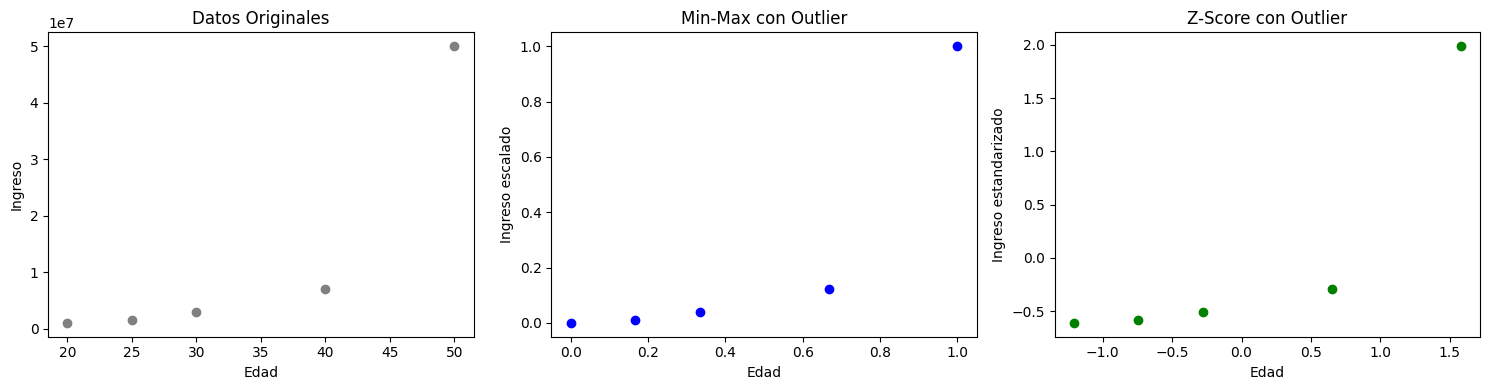

In [45]:
# =========================================
# EJERCICIO 1: OUTLIER EN INGRESO
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset con outlier
data_outlier = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50],
    'ingreso': [1000000, 1500000, 3000000, 7000000, 50000000]  # outlier: 50M
})

print("Datos con outlier:\n")
print(data_outlier)

# --- MIN-MAX ---
scaler_mm = MinMaxScaler()
minmax_outlier = pd.DataFrame(
    scaler_mm.fit_transform(data_outlier),
    columns=data_outlier.columns
)

print("\n Min-Max con outlier:\n")
print(minmax_outlier)

# --- Z-SCORE ---
scaler_z = StandardScaler()
zscore_outlier = pd.DataFrame(
    scaler_z.fit_transform(data_outlier),
    columns=data_outlier.columns
)

print("\n Z-Score con outlier:\n")
print(zscore_outlier)

# =========================================
# VISUALIZACIÓN COMPARATIVA
# =========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(data_outlier['edad'], data_outlier['ingreso'], color='gray')
axes[0].set_title("Datos Originales")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Ingreso")

axes[1].scatter(minmax_outlier['edad'], minmax_outlier['ingreso'], color='blue')
axes[1].set_title("Min-Max con Outlier")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Ingreso escalado")

axes[2].scatter(zscore_outlier['edad'], zscore_outlier['ingreso'], color='green')
axes[2].set_title("Z-Score con Outlier")
axes[2].set_xlabel("Edad")
axes[2].set_ylabel("Ingreso estandarizado")

plt.tight_layout()
plt.show()



**¿Qué pasa con Min-Max?**

El outlier 50000000 se convierte en 1.0, yo todos los demás valores quedan comprimidos mas cerca de 0. Ingresos de 1M a 7M que antes tenían diferencias visibles, ahora se ven muy similares entre el 0.0 y 0.12. El escalamiento pierde utilidad porque el outlier es demasiado distinto a los demas datos.

**¿Qué pasa con Z-Score**

El outlier aparece con un Z muy alto, indicando que está muy por encima del promedio.

Datos originales (solo edad):

   edad
0    20
1    25
2    30
3    40
4    50

 Min-Max (solo edad):

       edad
0  0.000000
1  0.166667
2  0.333333
3  0.666667
4  1.000000

 Z-Score (solo edad):

       edad
0 -1.207020
1 -0.742781
2 -0.278543
3  0.649934
4  1.578410


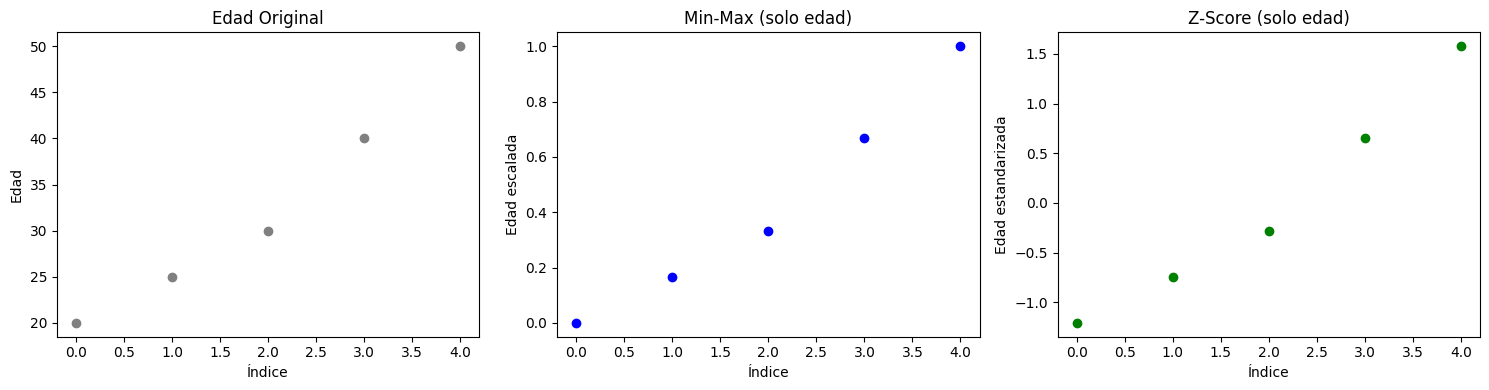

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data_edad = pd.DataFrame({
    'edad': [20, 25, 30, 40, 50]
})

print("Datos originales (solo edad):\n")
print(data_edad)

# --- MIN-MAX ---
scaler_mm = MinMaxScaler()
minmax_edad = pd.DataFrame(
    scaler_mm.fit_transform(data_edad),
    columns=data_edad.columns
)

print("\n Min-Max (solo edad):\n")
print(minmax_edad)

# --- Z-SCORE ---
scaler_z = StandardScaler()
zscore_edad = pd.DataFrame(
    scaler_z.fit_transform(data_edad),
    columns=data_edad.columns
)

print("\n Z-Score (solo edad):\n")
print(zscore_edad)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(range(len(data_edad)), data_edad['edad'], color='gray')
axes[0].set_title("Edad Original")
axes[0].set_xlabel("Índice")
axes[0].set_ylabel("Edad")

axes[1].scatter(range(len(minmax_edad)), minmax_edad['edad'], color='blue')
axes[1].set_title("Min-Max (solo edad)")
axes[1].set_xlabel("Índice")
axes[1].set_ylabel("Edad escalada")

axes[2].scatter(range(len(zscore_edad)), zscore_edad['edad'], color='green')
axes[2].set_title("Z-Score (solo edad)")
axes[2].set_xlabel("Índice")
axes[2].set_ylabel("Edad estandarizada")

plt.tight_layout()
plt.show()

**¿Tiene sentido escalar una sola variable?**

En la practica el escalar una sola variable tiene poco sentido ya que el escalamiento se realiza principalmente para que variables con diferentes magnitudes no dominen unas sobre otras en un modelo y si solamente hay una variable, no existe desequilibrio y la forma y distribución de los datos no cambia, solo cambia la escala numérica.

Esto serviría en caso de que se fuera a comparar contra otra variable externa o si el algoritmo requiere datos normalizados.

Datos originales con variable gasto:

   edad   ingreso    gasto
0    20   1000000   800000
1    25   1500000  1200000
2    30   3000000  2500000
3    40   7000000  4000000
4    50  10000000  6000000

 Min-Max (con gasto):

       edad   ingreso     gasto
0  0.000000  0.000000  0.000000
1  0.166667  0.055556  0.076923
2  0.333333  0.222222  0.326923
3  0.666667  0.666667  0.615385
4  1.000000  1.000000  1.000000

 Z-Score (con gasto):

       edad   ingreso     gasto
0 -1.207020 -1.010363 -1.098288
1 -0.742781 -0.866025 -0.889090
2 -0.278543 -0.433013 -0.209198
3  0.649934  0.721688  0.575294
4  1.578410  1.587713  1.621282


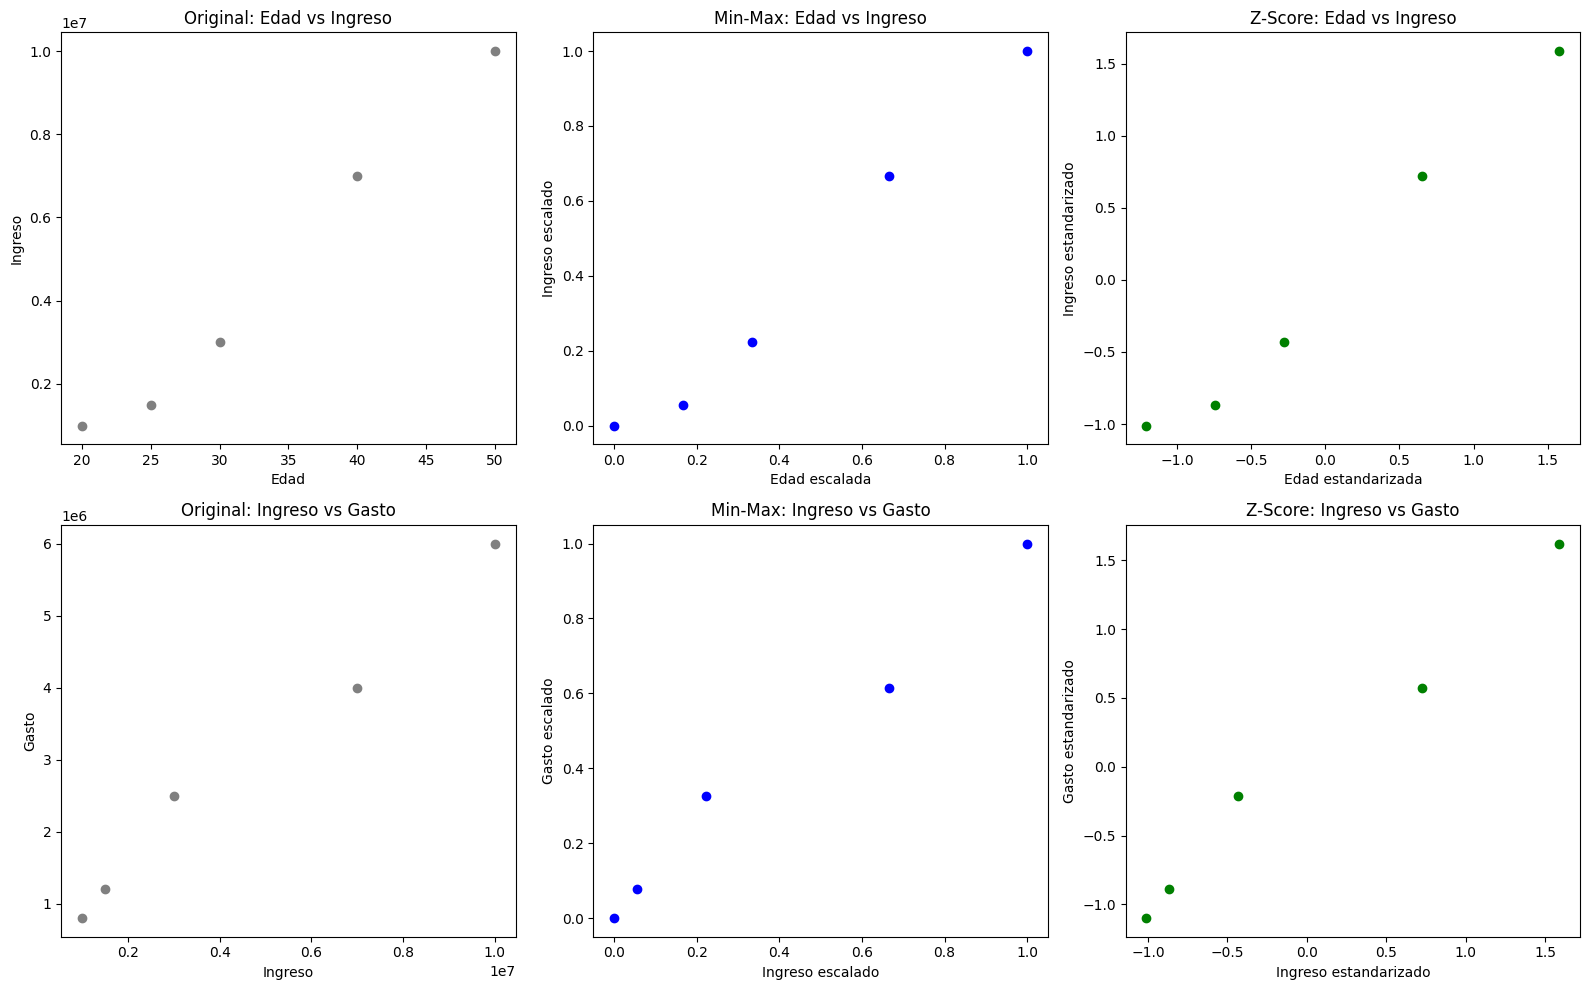


📊 Estadísticas Min-Max:

        edad  ingreso  gasto
count  5.000    5.000  5.000
mean   0.433    0.389  0.404
std    0.401    0.430  0.411
min    0.000    0.000  0.000
25%    0.167    0.056  0.077
50%    0.333    0.222  0.327
75%    0.667    0.667  0.615
max    1.000    1.000  1.000

📊 Estadísticas Z-Score:

        edad  ingreso  gasto
count  5.000    5.000  5.000
mean   0.000    0.000  0.000
std    1.118    1.118  1.118
min   -1.207   -1.010 -1.098
25%   -0.743   -0.866 -0.889
50%   -0.279   -0.433 -0.209
75%    0.650    0.722  0.575
max    1.578    1.588  1.621


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Dataset con nueva variable gasto
data = pd.DataFrame({
    'edad':   [20,      25,      30,      40,      50],
    'ingreso':[1000000, 1500000, 3000000, 7000000, 10000000],
    'gasto':  [800000,  1200000, 2500000, 4000000, 6000000]
})

print("Datos originales con variable gasto:\n")
print(data)

# --- MIN-MAX ---
scaler_mm = MinMaxScaler()
minmax_df = pd.DataFrame(
    scaler_mm.fit_transform(data),
    columns=data.columns
)

print("\n Min-Max (con gasto):\n")
print(minmax_df)

# --- Z-SCORE ---
scaler_z = StandardScaler()
zscore_df = pd.DataFrame(
    scaler_z.fit_transform(data),
    columns=data.columns
)

print("\n Z-Score (con gasto):\n")
print(zscore_df)

# =========================================
# VISUALIZACIÓN COMPARATIVA
# =========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Fila 1: edad vs ingreso
axes[0][0].scatter(data['edad'], data['ingreso'], color='gray')
axes[0][0].set_title("Original: Edad vs Ingreso")
axes[0][0].set_xlabel("Edad")
axes[0][0].set_ylabel("Ingreso")

axes[0][1].scatter(minmax_df['edad'], minmax_df['ingreso'], color='blue')
axes[0][1].set_title("Min-Max: Edad vs Ingreso")
axes[0][1].set_xlabel("Edad escalada")
axes[0][1].set_ylabel("Ingreso escalado")

axes[0][2].scatter(zscore_df['edad'], zscore_df['ingreso'], color='green')
axes[0][2].set_title("Z-Score: Edad vs Ingreso")
axes[0][2].set_xlabel("Edad estandarizada")
axes[0][2].set_ylabel("Ingreso estandarizado")

# Fila 2: ingreso vs gasto
axes[1][0].scatter(data['ingreso'], data['gasto'], color='gray')
axes[1][0].set_title("Original: Ingreso vs Gasto")
axes[1][0].set_xlabel("Ingreso")
axes[1][0].set_ylabel("Gasto")

axes[1][1].scatter(minmax_df['ingreso'], minmax_df['gasto'], color='blue')
axes[1][1].set_title("Min-Max: Ingreso vs Gasto")
axes[1][1].set_xlabel("Ingreso escalado")
axes[1][1].set_ylabel("Gasto escalado")

axes[1][2].scatter(zscore_df['ingreso'], zscore_df['gasto'], color='green')
axes[1][2].set_title("Z-Score: Ingreso vs Gasto")
axes[1][2].set_xlabel("Ingreso estandarizado")
axes[1][2].set_ylabel("Gasto estandarizado")

plt.tight_layout()
plt.show()

# =========================================
# ESTADÍSTICAS COMPARATIVAS
# =========================================

print("\n📊 Estadísticas Min-Max:\n")
print(minmax_df.describe().round(3))

print("\n📊 Estadísticas Z-Score:\n")
print(zscore_df.describe().round(3))

**¿Cuál método funciona mejor con la variable gasto?**

El método que funciona mejor para la variable gasto seria el Min-Max, esto suponiendo que los datos estén limpios y sin outliers ya que se mantiene una proporción real entre clientes. Pero en caso de que haya clientes con gastos muy atípicos es más recomendable utilizar el Z-Score, ya que este no distorsiona el resto de los datos.

# Creando la primer APP Web de Transformación

In [35]:
#PASO 0
!pip install streamlit

In [36]:
#PASO 1
%%writefile app.py
# =========================================
# 🚀 APP STREAMLIT: ESCALAMIENTO INTERACTIVO
# =========================================
# Ejecutar con:
# streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

st.title("Escalamiento de Datos Interactivo")

# Crear dataset simple
st.sidebar.header("Configuración de datos")
n = st.sidebar.slider("Número de datos", 5, 100, 20)

np.random.seed(42)
data = pd.DataFrame({
    'edad': np.random.randint(18, 60, n),
    'ingreso': np.random.randint(1000000, 10000000, n)
})

st.subheader("📊 Datos originales")
st.write(data)

# Selección de transformación
option = st.selectbox("Selecciona transformación:", ["Min-Max", "Z-Score"])

if option == "Min-Max":
    scaler = MinMaxScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Min-Max Scaling")
else:
    scaler = StandardScaler()
    transformed = scaler.fit_transform(data)
    st.success("Aplicando Z-Score")

transformed_df = pd.DataFrame(transformed, columns=data.columns)

st.subheader("📈 Datos transformados")
st.write(transformed_df)

# Visualización
fig, ax = plt.subplots()
ax.scatter(transformed_df['edad'], transformed_df['ingreso'])
ax.set_title("Visualización de datos transformados")
st.pyplot(fig)


# Visualización 2
plt.scatter(data['edad'], data['ingreso'])
plt.title("Datos originales")
plt.show()

st.write("\n🎯 Fin del laboratorio interactivo")


Overwriting app.py


In [37]:
#PASO 2
!streamlit run app.py &>/dev/null &

In [38]:
#PASO 3
!lsof -i:8501

COMMAND     PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
streamlit 31260 root   13u  IPv4 855405      0t0  TCP *:8501 (LISTEN)
streamlit 31260 root   14u  IPv6 855406      0t0  TCP *:8501 (LISTEN)


In [39]:
#PASO 4
#Previamente se debe crear una cuenta en ngrok: https://dashboard.ngrok.com/login
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!mv cloudflared /usr/local/bin/

# Lanzar la app primero (si no lo hiciste)
import subprocess, time, threading

# Lanzar Streamlit
subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.port=8501",
                  "--server.headless=true"])
time.sleep(4)

# Lanzar túnel cloudflare
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stderr=subprocess.PIPE
)

# Capturar la URL pública
import re
for line in tunnel.stderr:
    decoded = line.decode("utf-8")
    url_match = re.search(r"https://[a-z0-9\-]+\.trycloudflare\.com", decoded)
    if url_match:
        print("✅ Tu app está en:", url_match.group())
        break

✅ Tu app está en: https://ccd-tour-bunny-realty.trycloudflare.com


In [40]:
#PASO 5 - VALIDACIÓN DE DESPLIEGUE
!curl http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig